In [1]:
import pandas as pd
data = pd.read_excel('Intern_Applications_200_Rows.xlsx')
data.head()

,Application_ID,User_ID,Submission_Time,Age,CGPA,Submissions_Per_Minute
0,52,1197,09:30:39,23,3.62,1
1,23,1116,09:13:11,18,2.51,1
2,138,1200,09:48:11,28,3.17,1
3,56,1031,09:18:07,26,3.64,1
4,77,1061,09:02:33,21,3.82,1


In [3]:
X = data[['Age','CGPA','Submissions_Per_Minute']]

In [5]:
from sklearn.ensemble import IsolationForest
model = IsolationForest(contamination=0.1)
data['Anomaly'] = model.fit_predict(X)

In [6]:
anomalies = data[data['Anomaly'] == -1]
print(anomalies)

     Application_ID  User_ID Submission_Time  Age  CGPA  \
18              190     1133        09:44:40   60  4.31   
26              182     1161        09:42:01   17  0.71   
47              187     1003        09:09:32   45  0.92   
49              185     1124        09:10:59   60  3.22   
53              194     1015        09:54:07   60  5.00   
59              184     1166        09:59:08   16  2.64   
60              199     1027        09:16:24   45  2.29   
64               53     1046        09:26:06   30  2.12   
77              200     1109        09:25:46   45  4.43   
78              197     1146        09:30:06   60  4.20   
102             189     1139        09:16:36   45  0.72   
122             188     1103        09:51:12   17  4.12   
132             191     1101        09:42:01   45  2.32   
149             196     1047        09:22:03   16  3.52   
153             193     1101        09:20:39   17  3.53   
158             195     1160        09:42:08   17  2.18 

In [7]:
from sklearn.cluster import KMeans
KMeans = KMeans(n_clusters=2)
data['Cluster'] = KMeans.fit_predict(X)

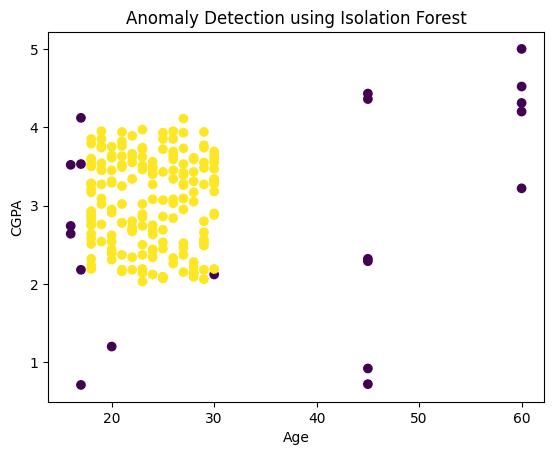

In [8]:
import matplotlib.pyplot as plt
plt.scatter(data['Age'],data['CGPA'],c=data['Anomaly'])
plt.xlabel('Age')
plt.ylabel('CGPA')
plt.title('Anomaly Detection using Isolation Forest')
plt.show()

In [9]:
for index, row in data.iterrows():
    if row['Anomaly'] == -1:
        print(f"Alert! Suspicious Application ID: {row['Application_ID']}")

Alert! Suspicious Application ID: 190
Alert! Suspicious Application ID: 182
Alert! Suspicious Application ID: 187
Alert! Suspicious Application ID: 185
Alert! Suspicious Application ID: 194
Alert! Suspicious Application ID: 184
Alert! Suspicious Application ID: 199
Alert! Suspicious Application ID: 53
Alert! Suspicious Application ID: 200
Alert! Suspicious Application ID: 197
Alert! Suspicious Application ID: 189
Alert! Suspicious Application ID: 188
Alert! Suspicious Application ID: 191
Alert! Suspicious Application ID: 196
Alert! Suspicious Application ID: 193
Alert! Suspicious Application ID: 195
Alert! Suspicious Application ID: 186
Alert! Suspicious Application ID: 183
Alert! Suspicious Application ID: 192
Alert! Suspicious Application ID: 181


## **Insights**
High submission frequency indicates possible bot activity    
Duplicate user IDs show repeated entries    
Extremely high or low CGPA values indicate invalid data     
Outlier ages suggest fake profiles